### **We use the existing model for glacier mapping**
#### Training stategy analysis    
|training    |miou(%)|oa(%) |kappa |precision(%)|recall(%)|note|     
|----        |----   |----  |----  |  ----      |    -    |  - |     
|from scrath |93.66  |98.40 |0.9322|97.17       |96.21    |    |      
|finetuning 1|94.87  |98.88 |0.9451|98.16       |96.50    |    |     
|finetuning 2|95.16  |98.91 |0.9486|98.10       |96.86    |    |        


In [2]:
import glob
import torch
import numpy as np
import pandas as pd
import rasterio as rio
from notebooks import config
from utils.imgShow import imsShow
from utils.img2patch import img2patch
from utils.metrics import metrics_segm
from model import unet, u2net, u2net_timm
import matplotlib.pyplot as plt

/home/xin/miniconda3/envs/glanet/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
paths_val_scene = config.paths_scene_val
paths_val_truth = config.paths_truth_val
paths_val_dem = config.paths_dem_val
dir_result_scratch = 'data/result/finetuning/from_scratch/'
dir_result_finetune1 = 'data/result/ablation_module/u2net_timm/'
dir_result_finetune2 = 'data/result/u3net_cross_fusion/'
paths_val_result_scratch = sorted(glob.glob(dir_result_scratch + '*.tif'))
paths_val_result_finetune1 = sorted(glob.glob(dir_result_finetune1 + '*.tif'))
paths_val_result_finetune2 = sorted(glob.glob(dir_result_finetune2 + '*.tif'))
print(len(paths_val_result_finetune2))



13


In [4]:
## read data
scenes, truths = [], []
for path_scene,  path_truth in zip(paths_val_scene, paths_val_truth):
    with rio.open(path_scene) as scene_rio:
        scene_arr = scene_rio.read()
        scene_arr = scene_arr.transpose((1, 2, 0))    ## (H,W,C)
        scenes.append(scene_arr)
    with rio.open(path_truth) as truth_rio:
        truth_arr = truth_rio.read(1)                ## (H,W)
        profile_truth = truth_rio.profile
        truths.append(truth_arr)



/tmp/ipykernel_996916/4026089258.py:9: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  truth_arr = truth_rio.read(1)                ## (H,W)


In [40]:
### read results
results_scratch, results_finetune1, results_finetune2 = [], [], []
for path_result_scratch, path_result_finetune1, path_result_finetune2 in zip(paths_val_result_scratch, paths_val_result_finetune1, paths_val_result_finetune2):
    with rio.open(path_result_scratch) as result_rio:
        result_arr = result_rio.read()[0]
        results_scratch.append(result_arr)
    with rio.open(path_result_finetune1) as result_rio:
        result_arr = result_rio.read()[0]
        results_finetune1.append(result_arr)
    with rio.open(path_result_finetune2) as result_rio:
        result_arr = result_rio.read()[0]
        results_finetune2.append(result_arr)


In [42]:
acc_metrics_scratch = pd.read_csv(dir_result_scratch + 'metrics_scenes.csv')
acc_metrics_finetune1 = pd.read_csv(dir_result_finetune1 + 'metrics_scenes.csv')
acc_metrics_finetune2 = pd.read_csv(dir_result_finetune2 + 'metrics_scenes.csv')
acc_metrics = pd.concat([acc_metrics_scratch[['Unnamed: 0','miou', 'kappa']], acc_metrics_finetune1[['miou', 'kappa']], acc_metrics_finetune2[['miou', 'kappa']]], axis=1)
acc_metrics.columns = ['scenes', 'miou_scratch', 'kappa_scratch', 'miou_finetune1', 'kappa_finetune1', 'miou_finetune2', 'kappa_finetune2']
acc_metrics


,scenes,miou_scratch,kappa_scratch,miou_finetune1,kappa_finetune1,miou_finetune2,kappa_finetune2
0,l5_scene_01,0.913404,0.907523,0.908180,0.901590,0.927978,0.923899
1,l5_scene_06,0.908893,0.902008,0.912641,0.906289,0.918276,0.912747
2,l5_scene_11,0.983993,0.983862,0.985237,0.985126,0.987541,0.987462
3,l7_scene_03,0.956451,0.955487,0.957333,0.956412,0.963953,0.963294
4,l7_scene_08,0.914343,0.910337,0.968285,0.967734,0.971105,0.970649
5,l7_scene_13,0.949885,0.947762,0.957443,0.955921,0.960728,0.959436
6,l8_scene_05,0.894201,0.882733,0.886434,0.873115,0.897633,0.886935
7,l8_scene_10,0.939450,0.937070,0.971007,0.970463,0.975566,0.975182
8,l9_scene_02,0.975370,0.974816,0.974515,0.973922,0.977494,0.977033
9,l9_scene_07,0.875342,0.861040,0.873832,0.859112,0.888279,0.876890


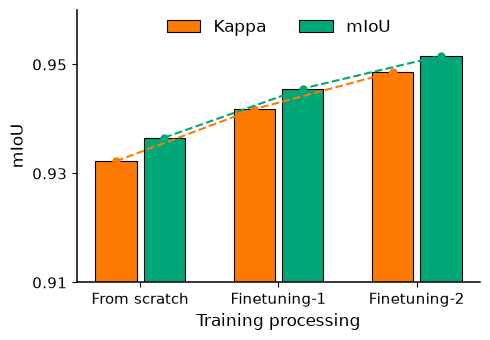

In [88]:
acc_methods = acc_metrics[acc_metrics['scenes']=='mean'].drop(columns='scenes')
acc_miou = acc_methods[['miou_scratch', 'miou_finetune1', 'miou_finetune2']]
acc_kappa = acc_methods[['kappa_scratch', 'kappa_finetune1', 'kappa_finetune2']]
colors = ["#00A878", "#FF7A00"]


fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(x = np.arange(3),
        height = acc_kappa.values.flatten(),
        width=0.3,
        color=colors[1],
        edgecolor="black",
        linewidth=0.8,
        label="Kappa"
        )
bars2 = ax.bar(x = np.arange(3)+0.35,
        height = acc_miou.values.flatten(),
        width=0.3,
        color=colors[0],
        edgecolor="black",
        linewidth=0.8,
        label="mIoU"
        )
plt.plot(np.arange(3), acc_kappa.values.flatten(), color=colors[1], linestyle='--', marker='o', markersize=5, linewidth=1.5)
plt.plot(np.arange(3)+0.35, acc_miou.values.flatten(), color=colors[0], linestyle='--', marker='o', markersize=5, linewidth=1.5)

# Add hatch patterns to make each bar visually distinct in slides and grayscale print.

ax.set_xticks([0+0.175,1+0.175,2+0.175],['From scratch', 'Finetuning-1', 'Finetuning-2'])
ax.set_xlabel("Training processing", fontsize=12)
ax.set_ylabel("mIoU", fontsize=12)
ax.tick_params(axis='both', labelsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_linewidth(1.1)
ax.legend(ncol=4, frameon=False, loc="lower center", fontsize=12, bbox_to_anchor=(0.5, 0.85))

ax.set_ylim(0.91, 0.96)
ax.set_yticks(np.arange(0.91, 0.96, 0.02))

plt.tight_layout()

